### drifting the periodically force Harper model?

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.integrate import odeint
import mpmath as mpmath
from scipy.optimize import linear_sum_assignment  # Hungarian algorithm 

# %matplotlib notebook 
%matplotlib inline 

import Husimi   # Quantum routines
import Harp     # Classical integration routines
import importlib  # for reloading routines if you need to edit them

### issues:
 explore drifting rate 

In [2]:
importlib.reload(Husimi)  # if you need to reload it!

<module 'Husimi' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Husimi.py'>

In [3]:
importlib.reload(Harp)  # if you need to reload it!

<module 'Harp' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Harp.py'>

In [4]:


# compute the propagator U across tau = (0 to 2 pi)  1 period 
# allowing time dependent variations of parameters during Trotterization
#  arguments:
#     N      : size of discrete quantum space
#     ntau   : how many Trotterized steps to take
#     parms0 = [a,b,eps,mu,mup]      : parameters of classical model, all unitless, 
#         at tau=0
#     d_parms = the rate of change in these parameters w.r.t tau.  parms = parms0 + tau*d_parms
#   Here tau ranges from 0 to 2pi, parms0 is value at the beginning of the period
#  returns:
#    Ufinal  : The 1 period propagator hat U_T  (NxN complex matrix)
#    w       : vector of eigenvalues of U_T in order of increasing phase 
#    vr      : vector of associated eigenfunctions of U
#            : with vr[:,j] is the eigenvector with eigenvalue w[j]
def U_prop2_var(N,ntau,parms0,d_parms):
    shift_by_pi = 0.
    taushift = 0.0 # could become a free parameter to pass
      
    DLambda_B =np.zeros((N,N),dtype=complex)  # storing diagonal matrix for phi part
    Efac = N/ntau    # Bohr Sommerfeld type quantization gives this
    # this is L_0/hbar x 2pi/ntau = N/2pi x 2pi/ntau = N/ntau, is correct , includes dtau

    #diagonals  used in construction 
    Dc= np.zeros(N,dtype=complex)
    Ds= np.zeros(N,dtype=complex)
    
    dtau = 2*np.pi/ntau  # step size for tau
    
    Q_FT,Q_FT_dagger = Husimi.QFT(N)  # need only be computed once, Fourier transform matrices

    #create some diagonals ahead of time, these are 1d arrays
    kvec = np.arange(N)  #integers from 0 to N-1
    pkvec = 2*np.pi*kvec/N  # frequencies or angles 
    Dc = np.cos(pkvec)
    Ds = np.sin(pkvec)
    phivec = pkvec # is the same thing really giving 2*np*j/N
    
    # half step at the beginning
    parms = parms0 + d_parms*taushift
    a = parms[0];  b = parms[1] 
    D_Ah = np.diag(np.exp(-0.5j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # exp works on each element of the array  
    # this is going to be equal to a(1-cos(hat p - b)), note that cos (p-b) = cos p cos b + sin p sin b
    # we contruct a matrix from a 1d array using numpy.diag()
    # is a half step because of 0.5  
    LAh  = np.matmul(Q_FT,np.matmul(D_Ah ,Q_FT_dagger)) # now go back into phi basis 
    
    U_final = LAh;  # half step at the beginning
        
    for i in range(ntau): # each dtau
        tau = i*dtau + taushift # time of propagator 
        parms = parms0 + d_parms*tau # parameters at each time!
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1]
        eps = parms[2]
        mu =  parms[3]
        mup =  parms[4]
        # full step, this is a*(1- cos (p-b)), because of -1
        D_A = np.diag(np.exp(-1j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # create a diagonal matrix 
        LA = np.matmul(Q_FT,np.matmul(D_A ,Q_FT_dagger)) #FT into phi basis 

        # create the diagonal 
        D_B_diag = np.exp(1j*Efac*(eps*np.cos(phivec) + mu*np.cos(phivec-tau) + mup*np.cos(phivec+tau)))
        # note sign of 1j (-1 * -1 = 1), 1=fullstep
        DLambda_B = np.diag(D_B_diag) # create a matrix now from the diagonal 
            
        U_final = np.matmul(LA,np.matmul(DLambda_B,U_final)) # mult by B and then A, full steps

    parms = parms0 + d_parms*(taushift + 2*np.pi - dtau)
    a = parms[0];  b = parms[1]   
    # is a half inverse step because of 0.5  
    D_Ah_inv = np.diag(np.exp(0.5j*Efac*a*(1.0-Dc*np.cos(b) - Ds*np.sin(b)))) # is a matrix
    LAh_inv     = np.matmul(Q_FT,np.matmul(D_Ah_inv ,Q_FT_dagger)) # now go back into phi basis 
    # apply inverse half step 
    U_final = np.matmul(LAh_inv,U_final)
    
    (w,vr)=np.linalg.eig(U_final)  # get eigenvalues and eigenvectors
    w_s,vr_s = Husimi.esort_phase(w,vr)   # sort in order of increasing eigenvalue phase
    return w_s,vr_s,U_final

    # this was tested with routine that does not drift during to make sure we computed a similar result

In [11]:

# record a series of eigenvalues for a series of operators 
# slowly and linearly varying parameters
# arguments:
#   n: dim of Hilbert space
#   ntau: number of Trotterization steps to take
#   parms: is [a,b,eps,mu,mup] for periodically perturbed Harper model
#   d_parms_period: is change in these values across a period
#   nseries: number of steps to take in our adiabatic variation, each step is a period
# returns:
#   U_list[nseries,n,n]  3 index matrix, storing propagators across each period
#   w_list[nseries,n]:  2 index matrix nseries, list of quasienergies for each UT at each step, increasing order (phase =quasienergies) 
#   vr_list[nseries,n,n]:  3 index matrix, list of eigenvecs for each UT, order phase 
#   wsort_list[nseries,n]:  list of quasienergies of current UT but in order <h_0> where h_0 is current operator h_0
#   vrsort_list[nseries,n,n]:  list of eigenvecs of current UT in order of <h_0>
#   expsort_list[nseries,n]:   list of <h_0> of current UT, increasing order of itself 
#   sigsort_list[nseries,n,n]: values of sig_h0 for current h0 but computed with eigenvecs of current UT, order <h_0>
#   U_trans_list[nseries,n,n]: product of all UTs up to this point (these are transition matrices)
# notes: 
# I checked that drifting during each period, was essentially equivalent to not doing this
#  but you have the option to do it either way now
#  if you set type_propagator to be 'var' or 'vanil' 
def U_prop_series(n,ntau,parms0,d_parms_period,nseries):
    #type_propagator = 'vanil' # if 'vanil' then use Husimi.U_prop2, otherwise use U_prop2_var() defined above 
    type_propagator = 'var'   # this choice makes it possible to drift slowly during each period!

    U_list =  np.zeros((nseries,n,n),dtype=complex) #   # place to store all propagators U_T (each across 1 period)
    w_list = np.zeros((nseries,n),dtype=complex)   # eigenvalues for the U_T of each period, order phase
    vr_list = np.zeros((nseries,n,n),dtype=complex) # eigenvecs for the U_T of each period, order phase
    wsort_list = np.zeros((nseries,n),dtype=complex)   #  eigenvalues for the U_T of each period, order current <h0>
    vrsort_list = np.zeros((nseries,n,n),dtype=complex) #  eigenvecs for the U_T of each period, order current <h0>
    expsort_list = np.zeros((nseries,n),dtype=complex)  # values of <h_0> for eigenvecs of U_T order increasing 
    sigsort_list = np.zeros((nseries,n),dtype=complex)  # values of dispersion <h0^2 - mean^2> for eigenvecs order current <h0>

    U_trans_list =  np.zeros((nseries,n,n),dtype=complex)  # make a record of all transition matrices along the series 
    # these are integrated up to current time 

    Ut = np.identity(n,dtype=complex) # Where we store the transition matrix  which is the product of all 1 period propagators
    taushift = 0.0

    d_parms = d_parms_period/(2*np.pi)  # this is the rate of change of parameters per unit tau time 


    # loop over each period that we are drifting 
    for i in range(nseries):
        parms = parms0 + i*d_parms_period
        # parms are the parameters at the begining of the period!!!!!
        a = parms[0] # note the order of the parameter list 
        b = parms[1]
        eps = parms[2] 
        h0_op = Husimi.hat_h_0_with_b(n,a,b,eps)  # unperturbed Hamiltonian (could vary so compute it in this loop)
        # this is h0 at the beginning of the period if a, b, eps are varying
        
        # create U propagator for this period
        if (type_propagator == 'vanil'): #  make it possible to choose which propagator function is being used  
            mu =  parms[3]
            mup = parms[4]
            w,vr,U =Husimi.U_prop2(n,ntau,a,b,eps,mu,mup,0.0)  # also returns eigenvals and eigenvecs in order of increasing phase
            # evaluated for values of parameters at the beginning of the period
        else:   # type_propagator == 'var'
            w,vr,U = U_prop2_var(n,ntau,parms,d_parms)  # variant above routine which lets all parameters vary within the routine 
            # here parms contains values of parameters at the beginning of the period
            # and d_parms is the rate of change of these parameters 

        w_list[i,:] = w      # eigenvalues of current U_T, in order of increasing quasi energy (phase)
        vr_list[i,:,:] = vr  # eigenvecs of current U_T, order phase
        U_list[i,:,:] = U    # store currrent propagator (for the 1 period)

        wsort,vrsort,expsort,sigsort = Husimi.esort_op(w,vr,h0_op)  # sort in order of h0_op for h0 at beginning of period 
        # note operator h0 is that at the beginning of period 
        wsort_list[i,:] = wsort   # eigenvalues (quasienergies) of current U_T, in order of increasing <h0>
        vrsort_list[i,:,:] = vrsort  # eigenvecs of current U_T, order <h0> 
        expsort_list[i,:] = expsort  # values of <h0> for eigenvecs of U_T order of increasing <h0>
        sigsort_list[i,:] = sigsort  # values of dispersion of h0, for eigenvecs of U_T same order 
        
        Ut = np.matmul(U,Ut)  # transition matrix up to current time, integrated propagator is updated 
        U_trans_list[i,:,:] = Ut   # store each transition matrix at each step of series
        
    # return 2d and 3d arrays of stuff 
    return U_list,w_list,vr_list,wsort_list,vrsort_list, expsort_list, sigsort_list, U_trans_list


In [16]:
colorlist = ['black','blueviolet','violet','blue','aqua','green','greenyellow','gold','peru','orange','red','maroon']
ncolors = len(colorlist)

# take the output of U_prop_series and compute transition matrices of 
#   amplitudes and phases  of <v_i|U_trans|v_j>   
#   |v_i> , eigenvecs of 1 period propagator at first time 
#   |v_j>,  eigenvecs of 1 period propagator at time k,
#    U_trans is propagator integrated to time k
# arguments:  
#    vrsort_list a set of eigenvectors  - each for instantaneous 1 period propagators 
#    U_trans_list the propagators computed at each period 
# k is which step in the series we want to use 
def comp_trans(vrsort_list,  U_trans_list, k):

    vr_first = np.squeeze(vrsort_list[0,:,:])  # eigenvecs of first UT
    vr_last = np.squeeze(vrsort_list[k,:,:])   # eigenvecs of desired UT
    U_trans = np.squeeze(U_trans_list[k,:,:])  # propagator integrated up to time k 
    
    n = vr_first.shape[0]
    t_matrix = np.zeros((n,n))  # for storing amplitudes 
    p_matrix = np.zeros((n,n))  # for storing phases 
    for i in range(n):
        u = np.squeeze(vr_first[:,i]) # i-th eigenvector of first set
        for j in range(n):
            v = np.squeeze(vr_last[:,j])  # j-th eigenvector of last set
            uUv = np.dot(u,np.matmul(U_trans,v))   # compute <u|U_trans|v>
            t_matrix[i,j] = np.abs(uUv) # compute magnitude and put it in a matrix 
            p_matrix[i,j] = np.angle(uUv) # compute phase and put it in a matrix 
    return t_matrix,p_matrix 



class drift_class():
    def __init__(self,n,ntau,parms0,d_parms_period,nseries):
        self.n = n
        self.ntau = ntau
        self.parms0 = parms0
        self.d_parms_period = d_parms_period
        self.nseries = nseries 
        U_list,w_list,vr_list,wsort_list,vrsort_list, expsort_list, sigsort_list, U_trans_list =\
              U_prop_series(n,ntau,parms0,d_parms_period,nseries)
        self.U_list = U_list
        self.w_list = w_list
        self.vr_list = vr_list
        self.wsort_list = wsort_list
        self.vrsort_list = vrsort_list
        self.expsort_list = expsort_list
        self.sigsort_list = sigsort_list
        self.U_trans_list = U_trans_list

        parms_final = self.parms0 + self.d_parms_period*self.nseries 
        self.a_final = parms_final[0]
        self.b_final = parms_final[1]
        self.eps_final = parms_final[2]
        self.mu_final = parms_final[3]
        self.mup_final = parms_final[4]
        print('a_final={:.4f} b_final={:.4f} eps_final={:.4f}'.format(self.a_final,self.b_final,self.eps_final))
        print('mu_final={:.4f} mup_final={:.4f}'.format(self.mu_final,self.mup_final))

        self.iis = np.arange(self.nseries)

    # compute transition matrices half way and full way through the series 
    def cp_trans(self):
        self.t_matrix_h,self.p_matrix_h = comp_trans(self.vrsort_list,  self.U_trans_list,int(self.nseries/2)) 
        self.t_matrix_e,self.p_matrix_e = comp_trans(self.vrsort_list,  self.U_trans_list,int(self.nseries-1)) 
        

In [40]:
# plots two matrices one next to another , both need to be real 
def plt2_trans(t_matrix,p_matrix,ofile):
    fig,axarr = plt.subplots(1,2,figsize=(4,2),sharex=True,sharey=True,dpi=200)
    plt.subplots_adjust(hspace=0,wspace=0)
    axarr[0].set_xticks([])
    axarr[0].set_yticks([])
    axarr[1].set_xticks([])
    axarr[1].set_yticks([])
    im0 = axarr[0].imshow(t_matrix,origin='lower')
    im1 = axarr[1].imshow(p_matrix,origin='lower')
    cax0=fig.add_axes([0.055,0.13,0.02,0.5])
    cax1=fig.add_axes([0.95,0.13,0.02,0.5])
    cbar0 = plt.colorbar(im0,cax=cax0,location='left')  
    cbar1 = plt.colorbar(im1,cax=cax1) 
    plt.show()


def plt2_trans_c(hclass,half_end,ofile):
    fig,axarr = plt.subplots(1,2,figsize=(4,2),sharex=True,sharey=True,dpi=200)
    plt.subplots_adjust(hspace=0,wspace=0)
    axarr[0].set_xticks([])
    axarr[0].set_yticks([])
    axarr[1].set_xticks([])
    axarr[1].set_yticks([])
    if (half_end == 'e'):
        im0 = axarr[0].imshow(hclass.t_matrix_e,origin='lower')
        im1 = axarr[1].imshow(hclass.p_matrix_e,origin='lower')
    else:
        im0 = axarr[0].imshow(hclass.t_matrix_h,origin='lower')
        im1 = axarr[1].imshow(hclass.p_matrix_h,origin='lower')
    cax0=fig.add_axes([0.055,0.13,0.02,0.5])
    cax1=fig.add_axes([0.95,0.13,0.02,0.5])
    cbar0 = plt.colorbar(im0,cax=cax0,location='left')  
    cbar1 = plt.colorbar(im1,cax=cax1) 
    plt.show()

# compute the transition matrix and eigenfunctions at beginning and end of series 
#U_list,w_list,vr_list,wsort_list,vrsort_list, expsort_list, sigsort_list, U_trans_list =\
#  U_prop_series(n,ntau,parms0,d_parms,nseries)
#t_matrix,p_matrix = comp_trans(xx1.vrsort_list,  xx1.U_trans_list,int(nseries/2))  # half way through 
#t_matrix2,p_matrix2 = comp_trans(xx1.vrsort_list,  xx1.U_trans_list,nseries-1)
#print(nseries*d_mu)

#plt2_trans(t_matrix,p_matrix)
#plt2_trans(t_matrix2,p_matrix2)

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=1.0000 mup_final=1.0000


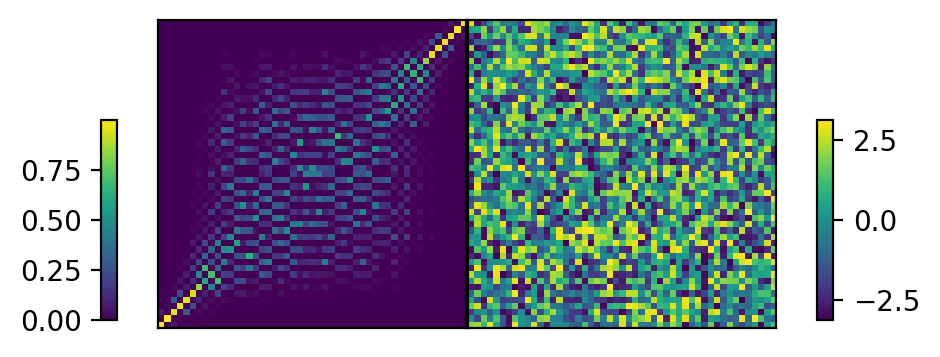

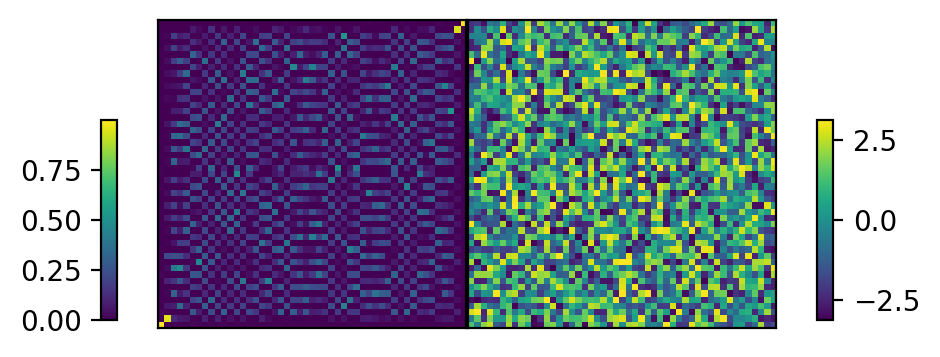

In [25]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.005; d_mup = d_mu  # increase chaotic region size 
nseries=200

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

xx1 = drift_class(n,ntau,parms0,d_parms,nseries)
xx1.cp_trans()  # compute transition matrices 

#plt2_trans(xx1.t_matrix_h,xx1.p_matrix_h,'')
#plt2_trans(xx1.t_matrix_e,xx1.p_matrix_e,'')
plt2_trans_c(xx1,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=1.0000 mup_final=1.0000


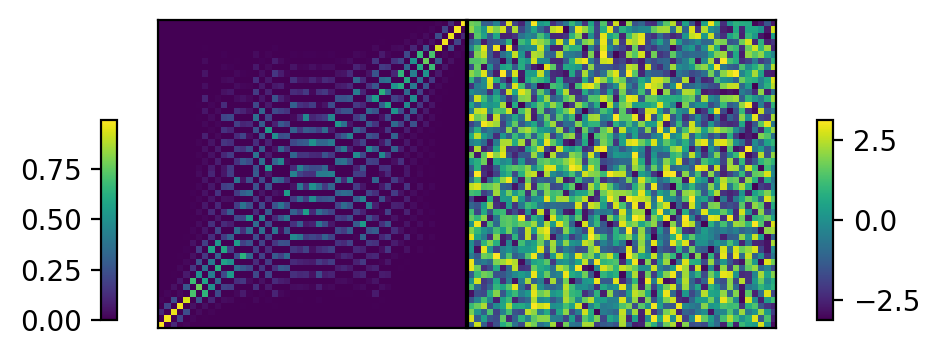

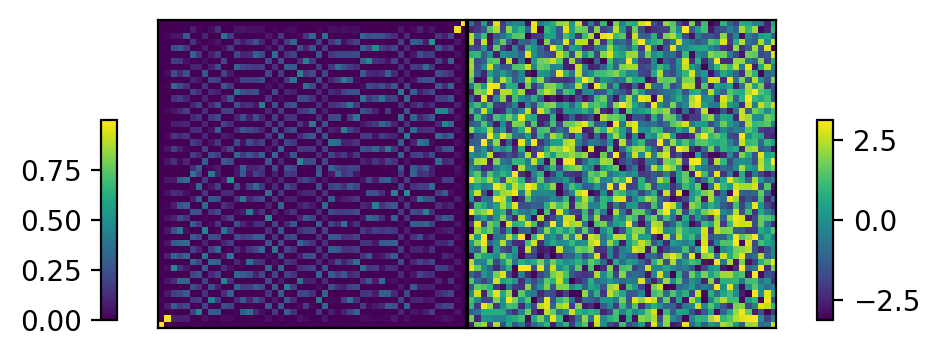

In [26]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.01; d_mup = d_mu  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

xx2 = drift_class(n,ntau,parms0,d_parms,nseries)
xx2.cp_trans()  # compute transition matrices 

#plt2_trans(xx2.t_matrix_h,xx2.p_matrix_h,'')
#plt2_trans(xx2.t_matrix_e,xx2.p_matrix_e,'')
plt2_trans_c(xx2,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=1.0000 mup_final=1.0000


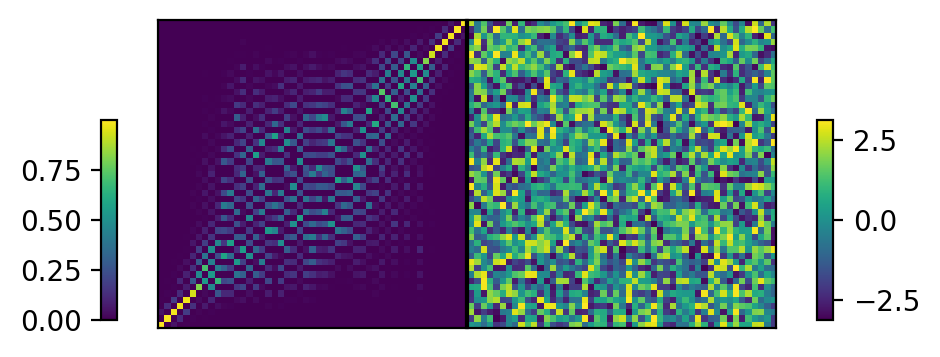

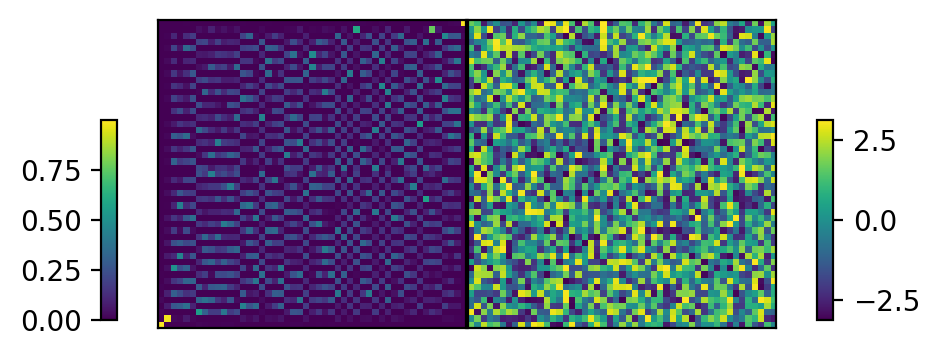

In [27]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.02; d_mup = d_mu  # increase chaotic region size 
nseries=50

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

xx3 = drift_class(n,ntau,parms0,d_parms,nseries)
xx3.cp_trans()  # compute transition matrices 

#plt2_trans(xx3.t_matrix_h,xx3.p_matrix_h,'')
#plt2_trans(xx3.t_matrix_e,xx3.p_matrix_e,'')
plt2_trans_c(xx3,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=1.0000 mup_final=1.0000


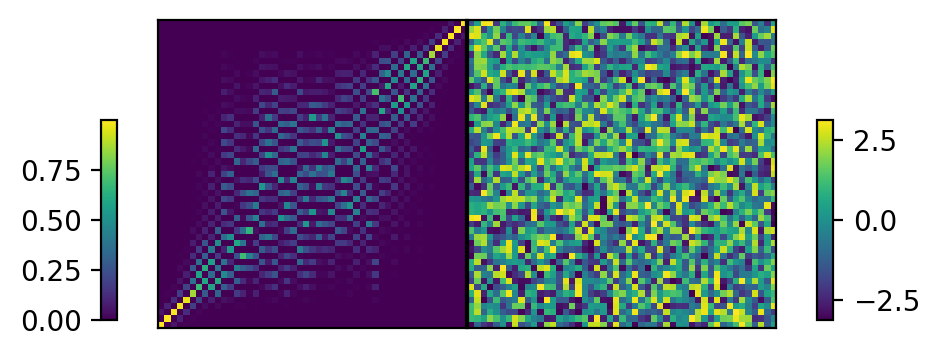

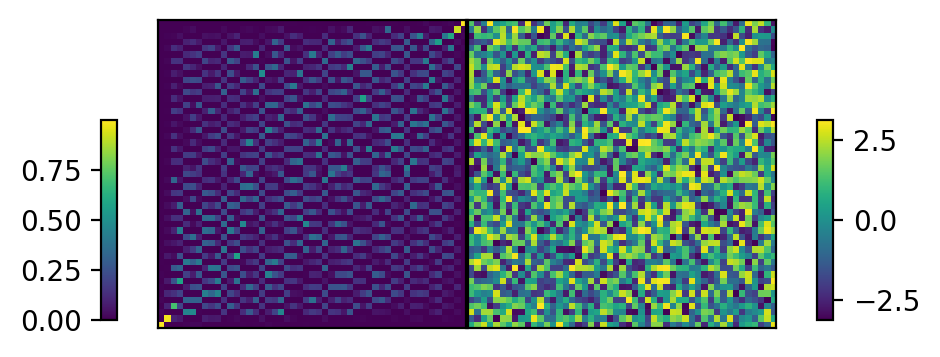

In [28]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.04; d_mup = d_mu  # increase chaotic region size 
nseries=25

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

xx4 = drift_class(n,ntau,parms0,d_parms,nseries)
xx4.cp_trans()  # compute transition matrices 

#plt2_trans(xx4.t_matrix_h,xx4.p_matrix_h,'')
#plt2_trans(xx4.t_matrix_e,xx4.p_matrix_e,'')
plt2_trans_c(xx4,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=1.0000 mup_final=1.0000


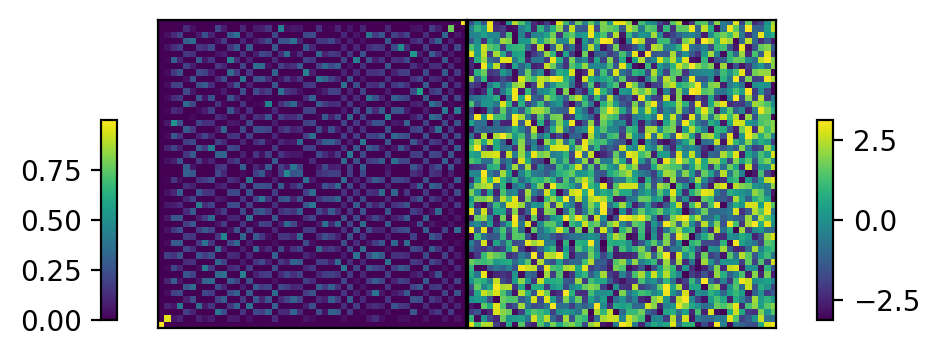

In [38]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.0025; d_mup = d_mu  # increase chaotic region size 
nseries=400

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

xx5 = drift_class(n,ntau,parms0,d_parms,nseries)
xx5.cp_trans()  # compute transition matrices 

#plt2_trans(xx4.t_matrix_h,xx4.p_matrix_h,'')
#plt2_trans(xx5.t_matrix_e,xx5.p_matrix_e,'')
plt2_trans_c(xx5,'e','')

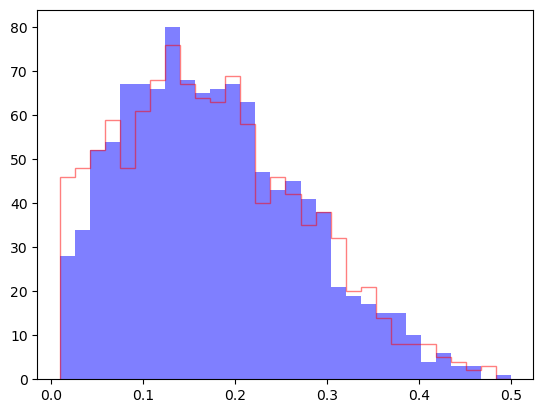

In [54]:
plt.hist(np.ravel(xx1.t_matrix_e),bins=30,alpha=0.5,range=[1e-2,0.5],color='red',histtype='step')
#plt.hist(np.ravel(xx4.t_matrix_e),bins=30,alpha=0.5,range=[1e-2,0.5])
plt.hist(np.ravel(xx5.t_matrix_e),bins=30,alpha=0.5,range=[1e-2,0.5],color='blue')
plt.show()

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


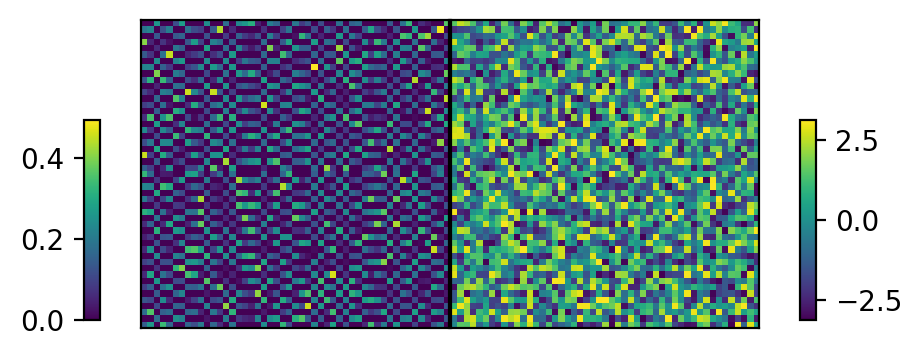

In [42]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.01; d_mup = d_mu  # increase chaotic region size 
nseries=200

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

yy1 = drift_class(n,ntau,parms0,d_parms,nseries)
yy1.cp_trans()  # compute transition matrices 

plt2_trans_c(yy1,'e','')


a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


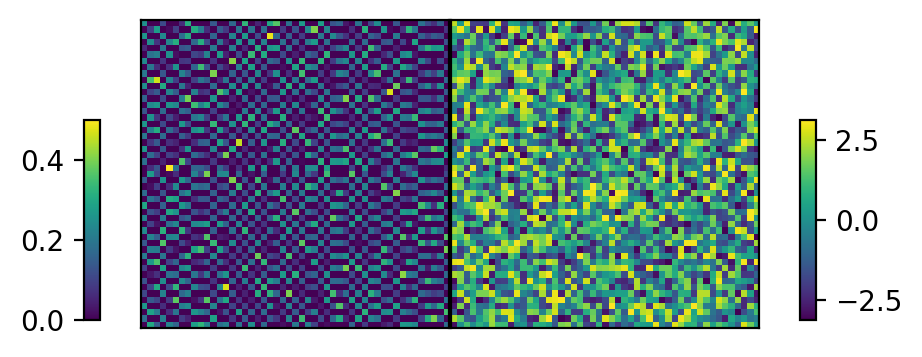

In [43]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.02; d_mup = d_mu  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

yy2 = drift_class(n,ntau,parms0,d_parms,nseries)
yy2.cp_trans()  # compute transition matrices 
plt2_trans_c(yy2,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


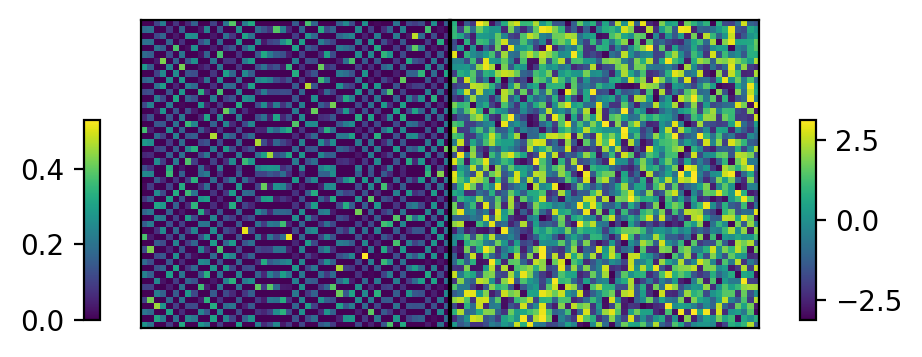

In [45]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.08; d_mup = d_mu  # increase chaotic region size 
nseries=25

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

yy3 = drift_class(n,ntau,parms0,d_parms,nseries)
yy3.cp_trans()  # compute transition matrices 
plt2_trans_c(yy3,'e','')

a_final=2.5000 b_final=0.0000 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


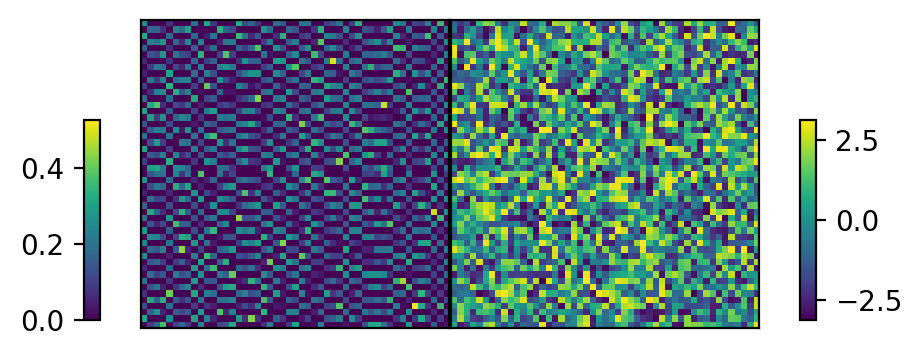

In [57]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.000; d_eps = 0.0; d_mu = 0.005; d_mup = d_mu  # increase chaotic region size 
nseries=400

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

yy4 = drift_class(n,ntau,parms0,d_parms,nseries)
yy4.cp_trans()  # compute transition matrices 
plt2_trans_c(yy4,'e','')

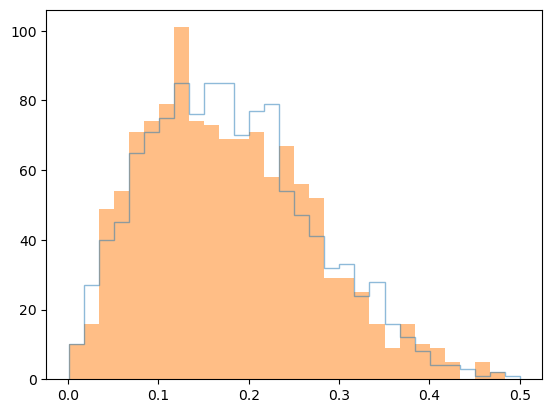

In [58]:
plt.hist(np.ravel(yy4.t_matrix_e),bins=30,alpha=0.5,range=[1e-3,0.5],histtype='step')  # slow one
#plt.hist(np.ravel(yy2.t_matrix_e),bins=30,alpha=0.5,range=[1e-3,0.5])
plt.hist(np.ravel(yy3.t_matrix_e),bins=30,alpha=0.5,range=[1e-3,0.5])  # fast one
plt.show()

a_final=2.5000 b_final=0.0200 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


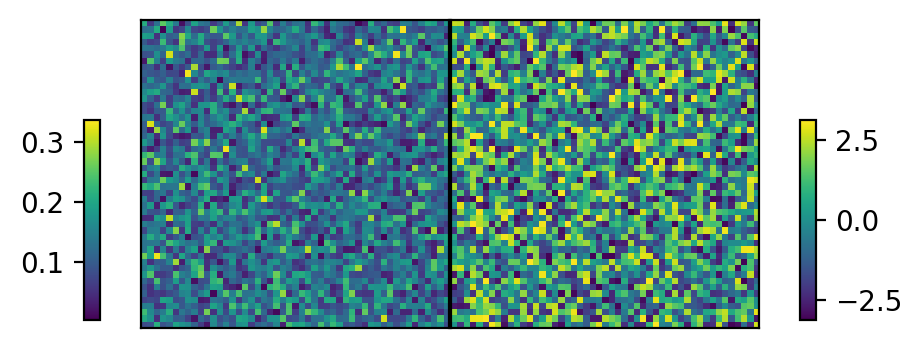

In [59]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.0001; d_eps = 0.0; d_mu = 0.01; d_mup = d_mu  # increase chaotic region size 
nseries=200

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

zz1 = drift_class(n,ntau,parms0,d_parms,nseries)
zz1.cp_trans()  # compute transition matrices 
plt2_trans_c(zz1,'e','')

a_final=2.5000 b_final=0.0200 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


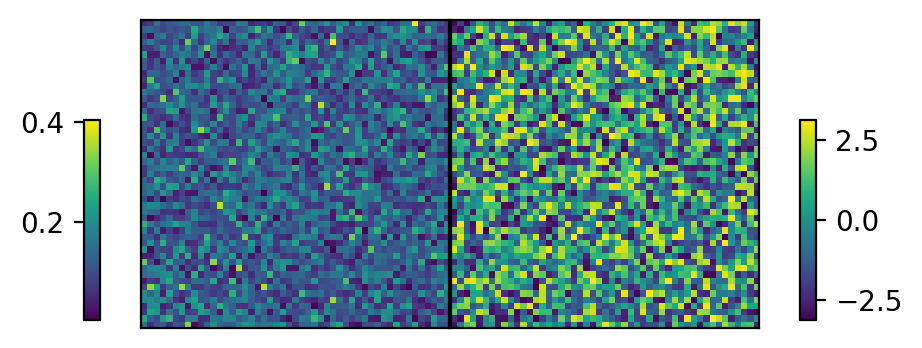

In [62]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.001; d_eps = 0.0; d_mu = 0.1; d_mup = d_mu  # increase chaotic region size 
nseries=20

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

zz2 = drift_class(n,ntau,parms0,d_parms,nseries)
zz2.cp_trans()  # compute transition matrices 
plt2_trans_c(zz2,'e','')

a_final=2.5000 b_final=0.0200 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


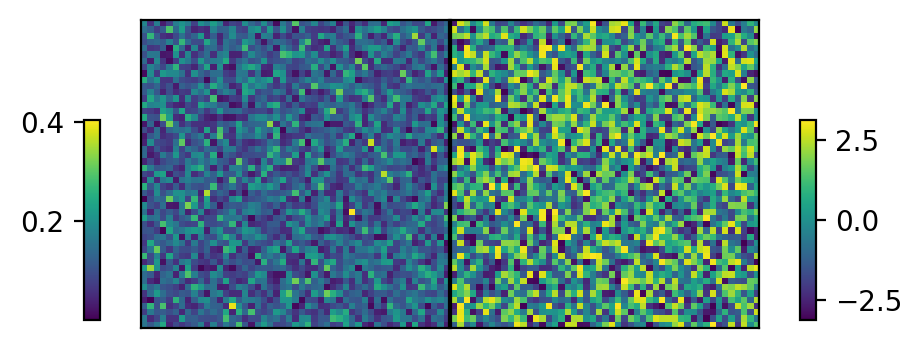

In [89]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 0.0; mup=mu;  
d_a = 0.0; d_b = 0.00005; d_eps = 0.0; d_mu = 0.005; d_mup = d_mu  # increase chaotic region size 
nseries=400

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

zz3 = drift_class(n,ntau,parms0,d_parms,nseries)
zz3.cp_trans()  # compute transition matrices 
plt2_trans_c(zz3,'e','')

the fit  [-0.10096646]


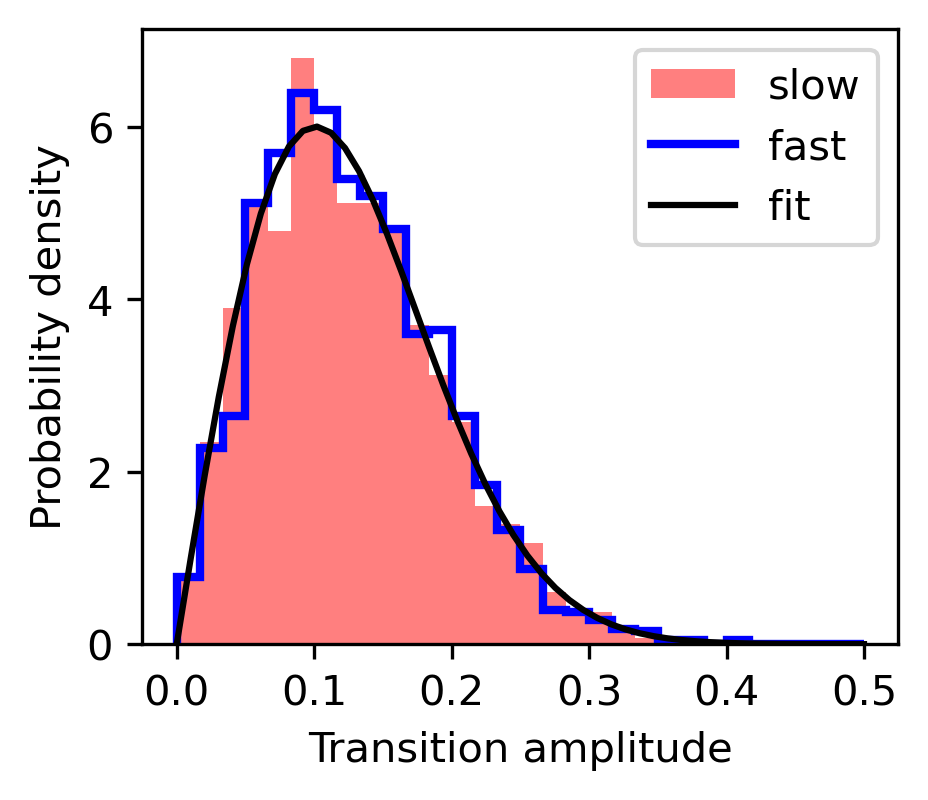

In [181]:
from scipy.optimize import curve_fit

#def func(x, a, b):
#    return a*x * np.exp(-0.5*(x/b)**2) # function to fit

def func(x, b):
    return b**-2 * x * np.exp(-0.5*(x/b)**2) # function to fit, is normalized so integral to infinity is 1

def plt2_amps(hclass1,hclass2,ofile):
    fig,ax = plt.subplots(1,1,figsize=(3,2.5),dpi=300)
    plt.subplots_adjust(left=0.15,top=0.99,right=0.99,bottom=0.17)
    counts, bin_edges = np.histogram(np.ravel(hclass1.t_matrix_e),bins=30,range=[0e-5,0.5],density=True)
    ww = bin_edges[1]- bin_edges[0]
    #ax.bar(bin_edges[0:-1],counts,align='edge',width=ww,edgecolor='red')
    ax.stairs(counts,bin_edges,facecolor='red',fill=True,alpha=0.5,label='slow') # edgecolor='red',
    counts2, bin_edges2 = np.histogram(np.ravel(hclass2.t_matrix_e),bins=30,range=[0e-5,0.5],density=True)
    ax.stairs(counts2,bin_edges2,edgecolor='blue',fill=False,lw=2,label='fast') # edgecolor='red',
    ax.set_xlabel('Transition amplitude')
    ax.set_ylabel('Probability density')
    popt, pcov = curve_fit(func, bin_edges[0:-1] + ww/2, counts)
    print('the fit ', popt)
    pfit = func(bin_edges[0:-1], *popt)  # fit to data 
    psmooth = func(a_lin,*popt)
    ax.plot(a_lin,psmooth,'k-',label='fit')
    ax.legend()
    if len(ofile)>3:
        plt.savefig(ofile)
    plt.show()
    
plt2_amps(zz3,zz2,'expfig.png')  # showing two different drift rates
# they have the same distribution of transition amplitudes 
# the black curve is a fit to the transition amplitude distribution 

a_final=2.5000 b_final=0.0200 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


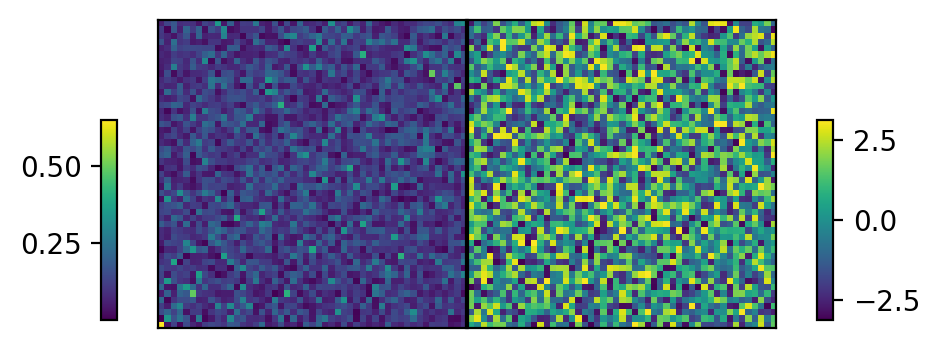

In [182]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 2.0; mup=mu;  
d_a = 0.0; d_b = 0.0001; d_eps = 0.0; d_mu = 0.00; d_mup = d_mu  # slowly drift b, for a very chaotic system
nseries=200

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

a1 = drift_class(n,ntau,parms0,d_parms,nseries)
a1.cp_trans()  # compute transition matrices 
plt2_trans_c(a1,'e','')

a_final=2.5000 b_final=0.0200 eps_final=2.5000
mu_final=2.0000 mup_final=2.0000


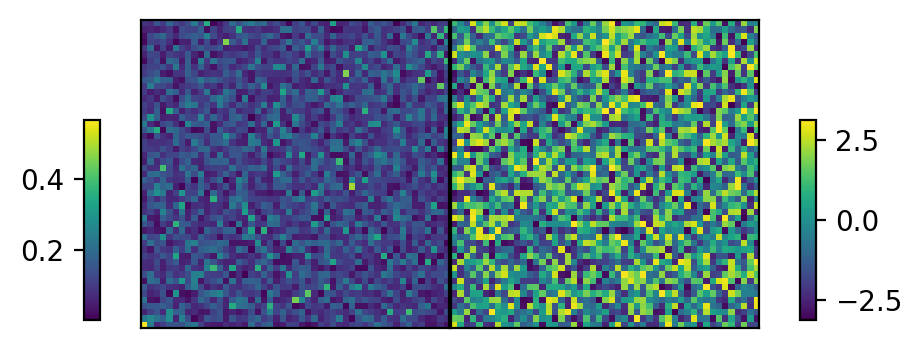

In [183]:
n=49; ntau=n*4;  a = 2.5; b=0; eps = 2.5; mu = 2.0; mup=mu;  
d_a = 0.0; d_b = 0.001; d_eps = 0.0; d_mu = 0.00; d_mup = d_mu  # slowly drift b, for a very chaotic system
nseries=20

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

a2 = drift_class(n,ntau,parms0,d_parms,nseries)
a2.cp_trans()  # compute transition matrices 
plt2_trans_c(a2,'e','')

the fit  [-0.09511801]


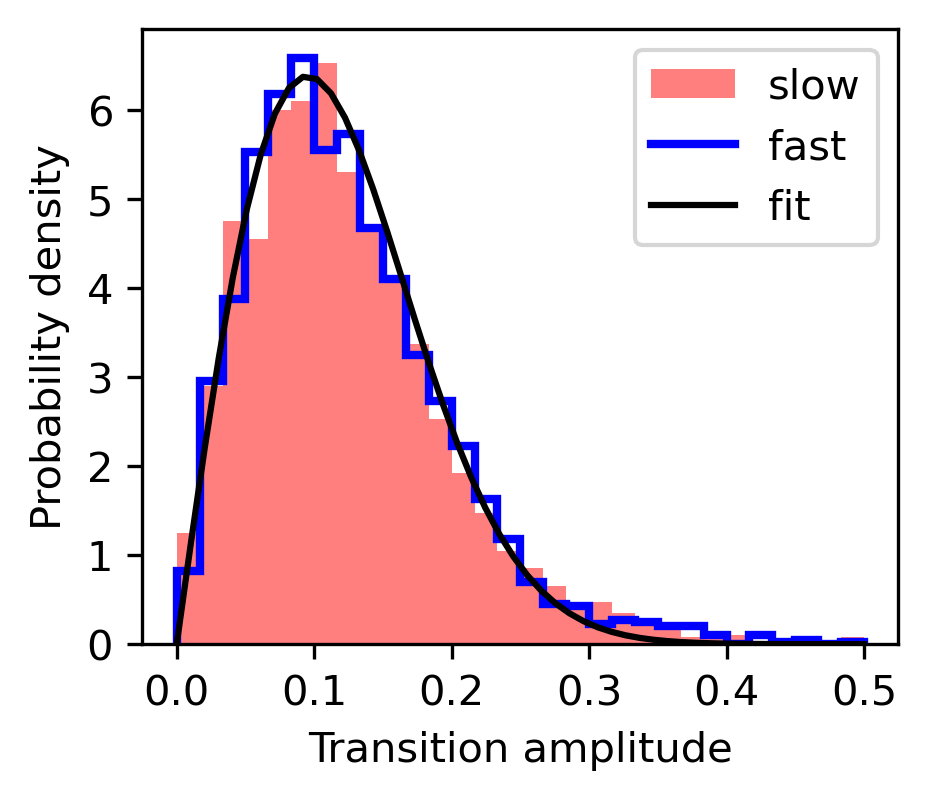

In [184]:
plt2_amps(a1,a2,'')

a_final=1.0000 b_final=0.0000 eps_final=1.0000
mu_final=0.0700 mup_final=0.0000


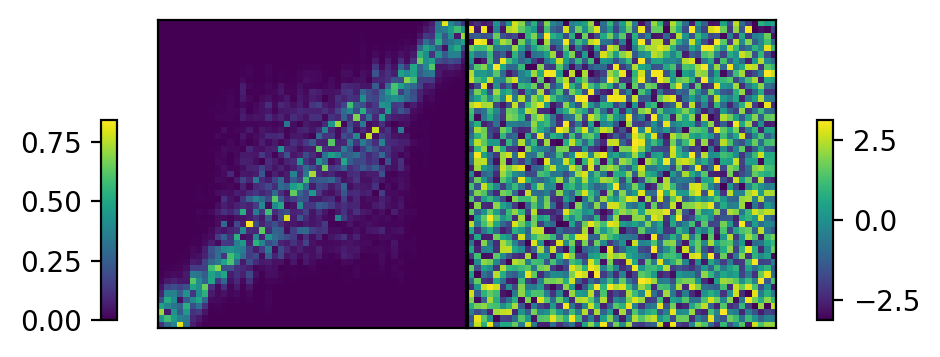

In [190]:
n=49; ntau=n*4;  a = 1.0; b=0; eps = a; mu = 0.03; mup=0;  
d_a = 0.0; d_b = 0.00; d_eps = 0.0; d_mu = 0.004; d_mup = 0  # increase chaotic region size 
nseries=10

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

bb1 = drift_class(n,ntau,parms0,d_parms,nseries)
bb1.cp_trans()  # compute transition matrices 
plt2_trans_c(bb1,'e','')

a_final=1.0000 b_final=0.0000 eps_final=1.0000
mu_final=0.0700 mup_final=0.0000


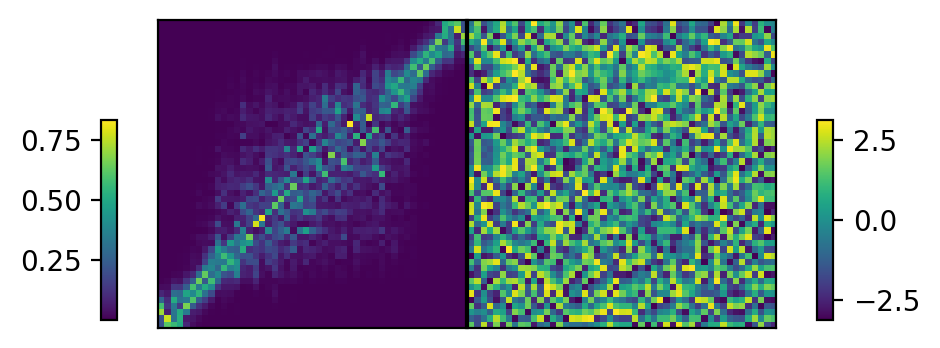

In [191]:
n=49; ntau=n*4;  a = 1.0; b=0; eps = a; mu = 0.03; mup=0;  
d_a = 0.0; d_b = 0.00; d_eps = 0.0; d_mu = 0.0004; d_mup = 0  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

bb2 = drift_class(n,ntau,parms0,d_parms,nseries)
bb2.cp_trans()  # compute transition matrices 
plt2_trans_c(bb2,'e','')

the fit  [0.72756236]


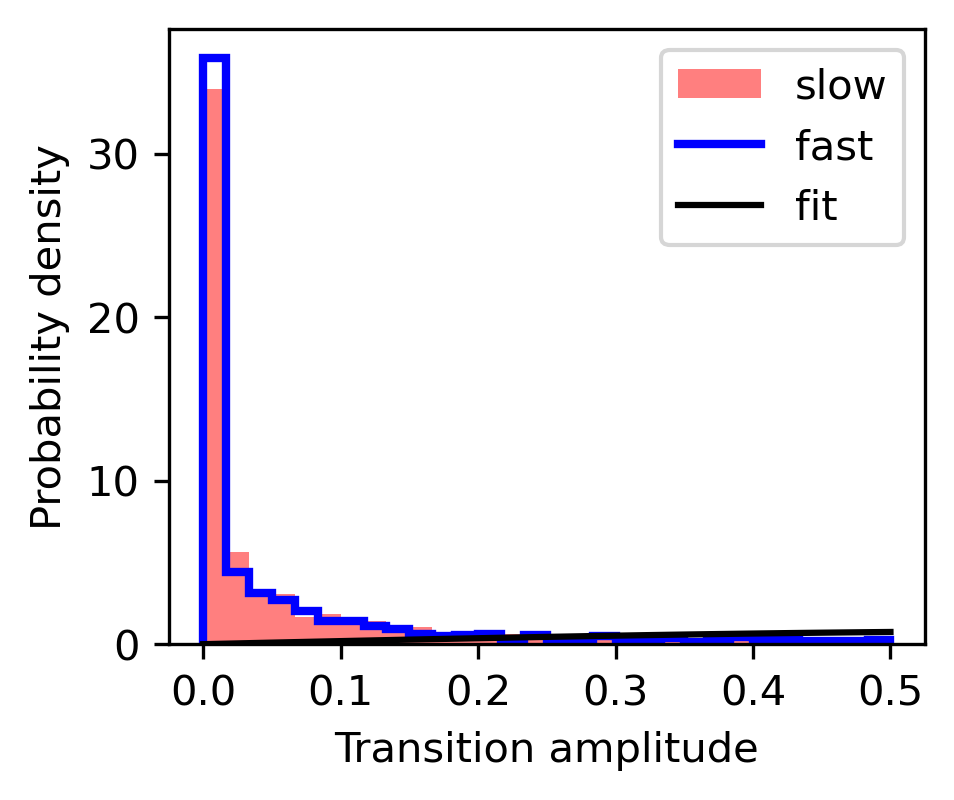

In [192]:
plt2_amps(bb2,bb1,'')

a_final=1.0000 b_final=0.0000 eps_final=1.0000
mu_final=0.0700 mup_final=0.0000


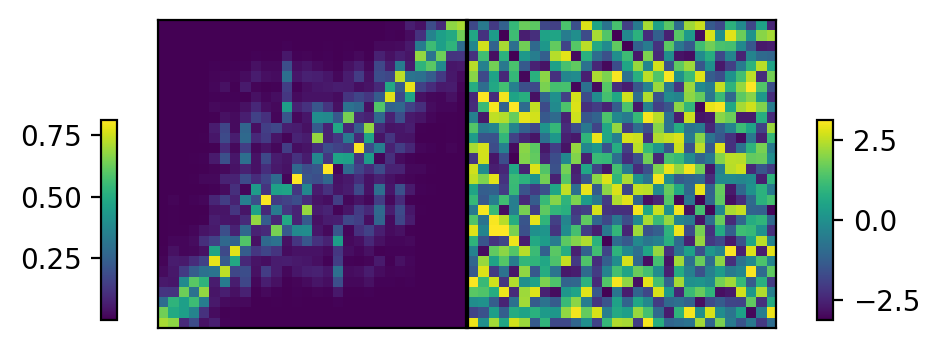

In [193]:
n=30; ntau=n*4;  a = 1.0; b=0; eps = a; mu = 0.03; mup=0;  
d_a = 0.0; d_b = 0.00; d_eps = 0.0; d_mu = 0.0004; d_mup = 0  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

bb3 = drift_class(n,ntau,parms0,d_parms,nseries)
bb3.cp_trans()  # compute transition matrices 
plt2_trans_c(bb3,'e','')

a_final=1.0000 b_final=0.0000 eps_final=1.0000
mu_final=0.0700 mup_final=0.0000


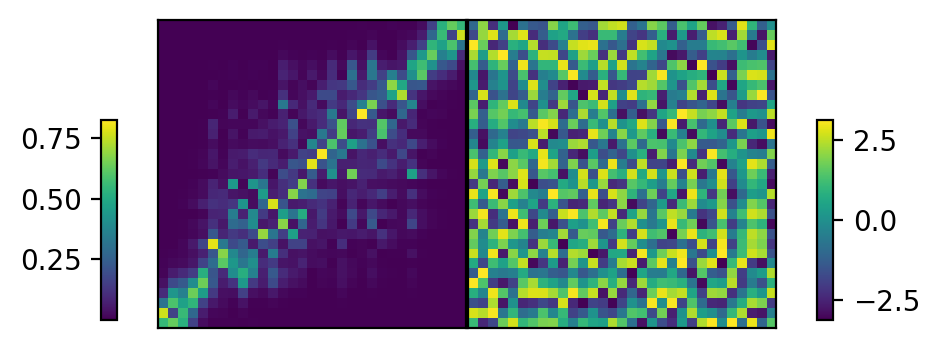

In [194]:
n=31; ntau=n*4;  a = 1.0; b=0; eps = a; mu = 0.03; mup=0;  
d_a = 0.0; d_b = 0.00; d_eps = 0.0; d_mu = 0.0004; d_mup = 0  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

bb3 = drift_class(n,ntau,parms0,d_parms,nseries)
bb3.cp_trans()  # compute transition matrices 
plt2_trans_c(bb3,'e','')

a_final=1.0000 b_final=0.0000 eps_final=1.0000
mu_final=0.0700 mup_final=0.0000


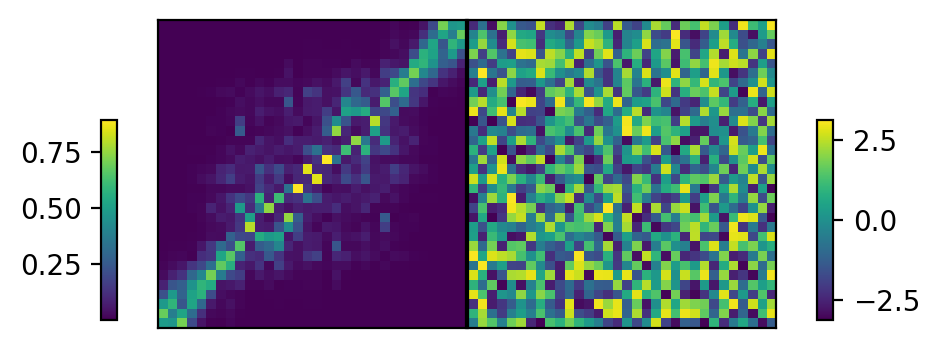

In [195]:
n=32; ntau=n*4;  a = 1.0; b=0; eps = a; mu = 0.03; mup=0;  
d_a = 0.0; d_b = 0.00; d_eps = 0.0; d_mu = 0.0004; d_mup = 0  # increase chaotic region size 
nseries=100

parms0 = np.array([a,b,eps,mu,mup])
d_parms = np.array([d_a,d_b,d_eps,d_mu,d_mup])

bb3 = drift_class(n,ntau,parms0,d_parms,nseries)
bb3.cp_trans()  # compute transition matrices 
plt2_trans_c(bb3,'e','')